# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:   
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.



Sumber dataset : Kaggle  
Nama dataset : Jakarta House Price Dataset  
Link dataset : https://www.kaggle.com/datasets/abiyyurasyiq/jakarta-house-price-dataset

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [18]:
file_id = '1DsEyjndh1ONsT3LOqhLQDsqLQjwVb9pf'
url = f'https://drive.google.com/uc?id={file_id}'

# Download file
output = 'harga_rumah_jkt_dataset.csv'
gdown.download(url, output, quiet=False)

file = 'harga_rumah_jkt_dataset.csv'
df  = pd.read_csv(file)
print("Data loaded successfully. Displaying the first 5 rows:")
display(df.head())

Downloading...
From: https://drive.google.com/uc?id=1DsEyjndh1ONsT3LOqhLQDsqLQjwVb9pf
To: /content/harga_rumah_jkt_dataset.csv
100%|██████████| 569k/569k [00:00<00:00, 6.94MB/s]

Data loaded successfully. Displaying the first 5 rows:


,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## 1. Overall view

In [19]:
print("\n--- Dataset Information ---")
df.info()

print("\n--- Descriptive Statistics ---")
df.describe()


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          10000 non-null  int64  
 1   price          10000 non-null  int64  
 2   district       10000 non-null  object 
 3   city           10000 non-null  object 
 4   bed_rooms      10000 non-null  int64  
 5   bath_rooms     10000 non-null  int64  
 6   carport        10000 non-null  int64  
 7   land_area      9997 non-null   float64
 8   building_area  9995 non-null   float64
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB

--- Descriptive Statistics ---


,index,price,bed_rooms,bath_rooms,carport,land_area,building_area
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
mean,5000.50000,1.004029e+10,4.253500,3.521300,1.578900,296.610183,319.962481
std,2886.89568,2.004519e+10,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.00000,1.850000e+06,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2500.75000,2.500000e+09,3.000000,2.000000,1.000000,100.000000,139.000000
50%,5000.50000,4.500000e+09,4.000000,3.000000,1.000000,177.000000,230.000000
75%,7500.25000,9.800000e+09,5.000000,4.000000,2.000000,335.000000,400.000000
max,10000.00000,9.000000e+11,63.000000,63.000000,31.000000,17714.000000,15331.000000


## 2. Correlation Matrix


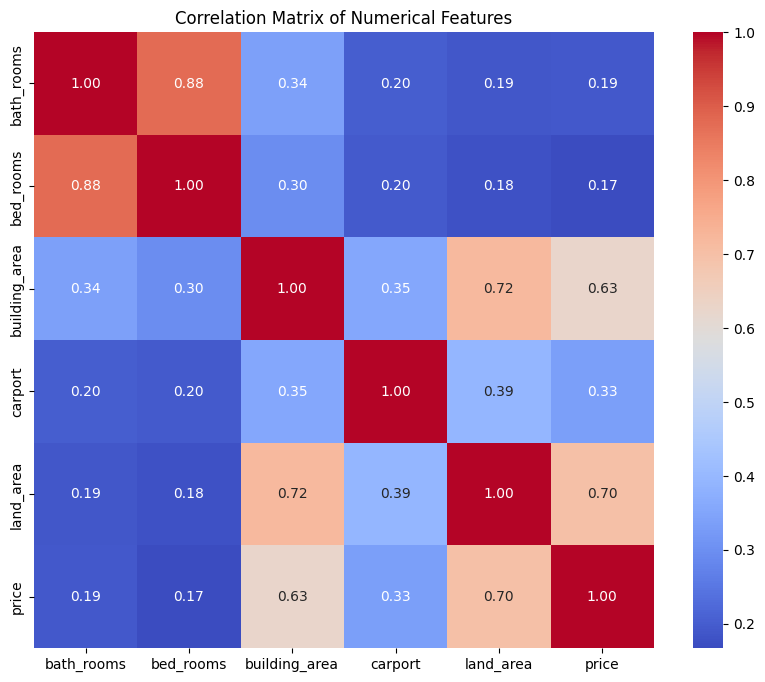

In [20]:
# Select only numerical columns for correlation calculation
cols_to_exclude = ['index']
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_df = df[numeric_cols.difference(cols_to_exclude)]

if not numeric_df.empty:
    correlation_matrix = numeric_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()
else:
    print("No numerical columns found to compute correlation.")

## 3.Histogram fitur desrtribution

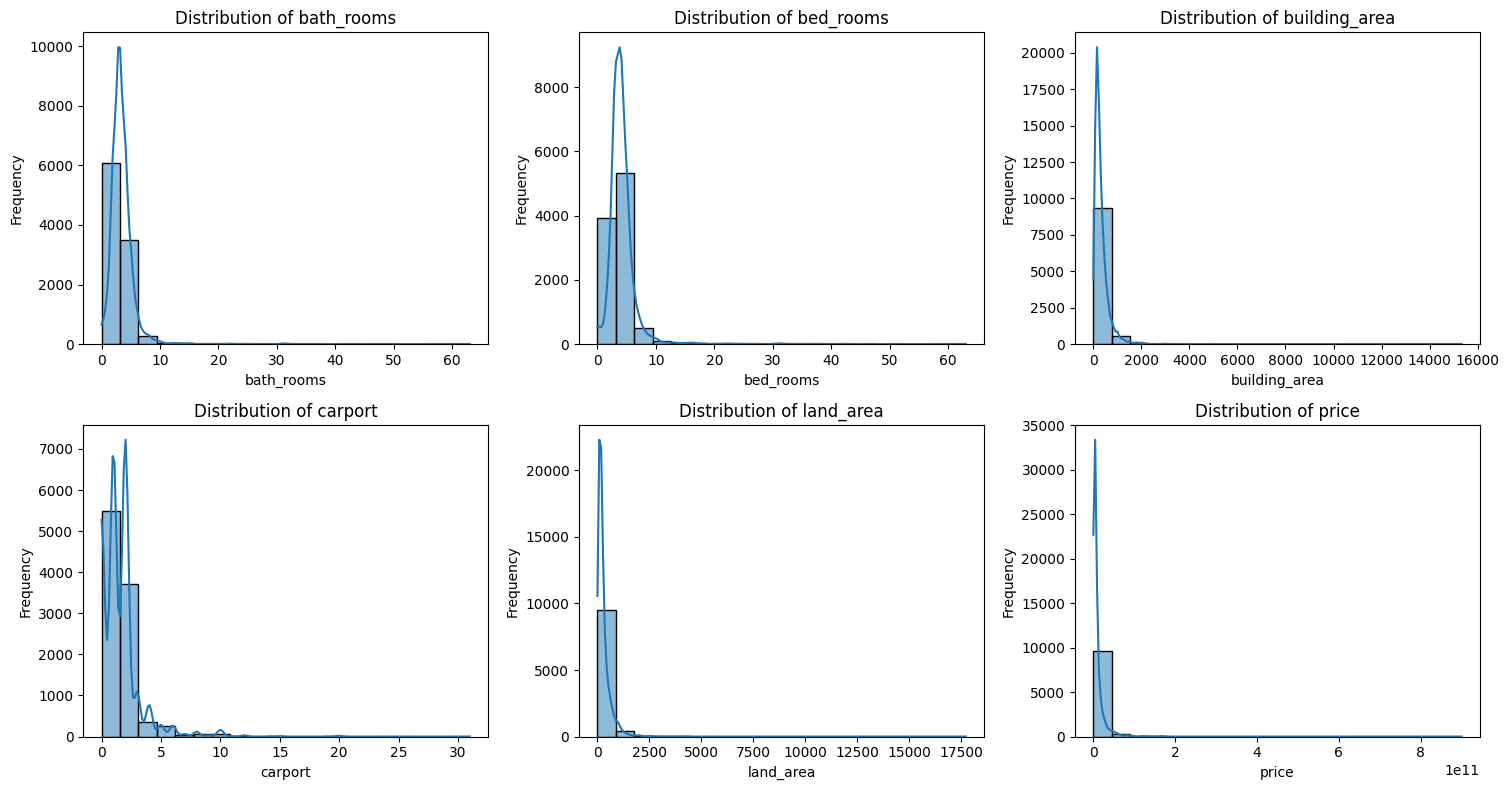

In [21]:
if not numeric_df.empty:
    # Penentuan untuk barisan tampilan
    n_cols = 3
    n_rows = (len(numeric_df.columns) + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 4))

    for i, column in enumerate(numeric_df.columns):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.histplot(numeric_df[column], kde=True, bins=20)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns available for histograms.")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## 1. Missing Values

In [22]:
df.isnull().sum()

,0
index,0
price,0
district,0
city,0
bed_rooms,0
bath_rooms,0
carport,0
land_area,3
building_area,5


In [23]:
df.dropna(inplace=True)
df.isnull().sum()

,0
index,0
price,0
district,0
city,0
bed_rooms,0
bath_rooms,0
carport,0
land_area,0
building_area,0


## 2. Duplicated data check

In [24]:
df.duplicated().sum()

np.int64(0)

## 3. Outliers Handling


In [25]:
current_numeric_cols = df.select_dtypes(include=['number']).columns

for col in current_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Melakukan filtering outlier
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Penanganan outlier selesai. Ringkasan statistik dataset baru:")
display(df.describe())

Penanganan outlier selesai. Ringkasan statistik dataset baru:


,index,price,bed_rooms,bath_rooms,carport,land_area,building_area
count,7523.000000,7.523000e+03,7523.000000,7523.000000,7523.000000,7523.00000,7523.000000
mean,4996.679250,4.344571e+09,3.631929,2.971953,1.173468,160.12814,205.470956
std,2885.168274,3.329495e+09,1.222181,1.112944,0.824916,95.10038,114.824718
min,1.000000,1.850000e+06,0.000000,0.000000,0.000000,9.00000,1.000000
25%,2501.500000,2.100000e+09,3.000000,2.000000,1.000000,90.00000,120.000000
50%,5043.000000,3.300000e+09,4.000000,3.000000,1.000000,135.00000,180.000000
75%,7468.500000,5.600000e+09,4.000000,4.000000,2.000000,205.00000,274.000000
max,9999.000000,2.050000e+10,8.000000,7.000000,3.000000,480.00000,570.000000


## 4. Pemisahan fitur & Target + Split data

In [26]:
X = df.drop('price', axis=1)
y = df['price']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Encoding (Target Encoding)


In [28]:
!pip install category_encoders
import category_encoders as ce
# Inisialisasi target encoder dengan smoothing
# smoothing: semakin besar nilai, semakin kuat regularisasi (hindari overfitting)
encoder = ce.TargetEncoder(cols=['district', 'city'], smoothing=10)

# Fit pada TRAINING DATA saja, lalu transform
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)


## 6. Feature Scaling

In [29]:
# Inisialisasi Scaler
scaler = StandardScaler()

# Fit pada data training yang sudah di-encode, kemudian transform keduanya
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Konversi kembali ke DataFrame untuk kemudahan pembacaan (opsional)
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

print("Scaling selesai. Statistik data training setelah scaling:")
display(X_train_final.describe().round(2))

Scaling selesai. Statistik data training setelah scaling:


,index,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,6018.00,6018.00,6018.00,6018.00,6018.00,6018.00,6018.00,6018.00
mean,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.74,-1.48,-1.39,-2.96,-2.67,-1.43,-1.58,-1.78
25%,-0.85,-0.67,-0.56,-0.51,-0.88,-0.22,-0.74,-0.74
50%,0.01,-0.19,-0.56,0.30,0.02,-0.22,-0.26,-0.22
75%,0.85,0.37,1.29,0.30,0.92,0.99,0.47,0.56
max,1.73,3.84,1.29,3.56,3.61,2.21,3.34,3.17


##6. Distribusi price miring

In [30]:
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)